In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import nibabel as nib
from pathlib import Path

from nilearn import image, masking, plotting, datasets
from nilearn.maskers import NiftiMasker

from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA, FastICA
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

from scipy.stats import zscore, pearsonr, ttest_ind
from statsmodels.stats.multitest import fdrcorrection

import warnings
warnings.filterwarnings("ignore")


data_dir = Path("/Users/zehuasong/Desktop/Schizophrenia_Project/data")

TR = 2.0
n_pca = 120
n_ic = 25
random_state = 42
test_size = 0.3


# Find all fMRI files
func_files = sorted(data_dir.glob("fmri_*.nii.gz"))

# Load phenotype file
phenotype_file = data_dir / "phenotypic_data.tsv.gz"
pheno = pd.read_csv(phenotype_file, sep="\t")

# Format subject IDs
pheno["ID"] = pheno["ID"].astype(str).str.zfill(7)
pheno_indexed = pheno.set_index("ID")

# Extract subject IDs from filenames
subject_ids = [
    f.name.replace("fmri_", "").replace(".nii.gz", "")
    for f in func_files
]

# Store matched data
labels = []
ages = []
genders = []
fd_scrubbed = []

valid_func_files = []
valid_subject_ids = []

# Match fMRI files with phenotype information
for f, sid in zip(func_files, subject_ids):

    if sid in pheno_indexed.index:

        valid_func_files.append(f)
        valid_subject_ids.append(sid)

        labels.append(pheno_indexed.loc[sid, "Subject Type"])
        ages.append(pheno_indexed.loc[sid, "Current Age"])
        genders.append(pheno_indexed.loc[sid, "Gender"])
        fd_scrubbed.append(pheno_indexed.loc[sid, "FD Scrubbed"])


# Convert Python lists to NumPy arrays
func_files = np.array(valid_func_files)
subject_ids = np.array(valid_subject_ids)
labels = np.array(labels)
ages = np.array(ages)
genders = np.array(genders)
fd_scrubbed = np.array(fd_scrubbed)


#remove short scan

# This subject has only 67 functional volumes,
# so it is excluded before train/test split.
bad_sid = "0040075"

keep_mask = subject_ids != bad_sid

func_files = func_files[keep_mask]
subject_ids = subject_ids[keep_mask]
labels = labels[keep_mask]
ages = ages[keep_mask]
genders = genders[keep_mask]
fd_scrubbed = fd_scrubbed[keep_mask]


# Convert diagnostic labels to binary values
# Control = 0, Patient = 1
y = (labels == "Patient").astype(int)


# Combine subject information into a DataFrame
subject_info = pd.DataFrame({
    "ID": subject_ids,
    "Subject Type": labels,
    "y": y,
    "Age": ages,
    "Gender": genders,
    "FD Scrubbed": fd_scrubbed
})


print("Removed subject:", bad_sid)
print(subject_info["Subject Type"].value_counts())
print("Number of subjects:", len(subject_info))

subject_info.head()

Removed subject: 0040075
Control    74
Patient    71
Name: Subject Type, dtype: int64
Number of subjects: 145


,ID,Subject Type,y,Age,Gender,FD Scrubbed
0,0040000,Patient,1,20,Female,0.20245
1,0040001,Patient,1,27,Male,1.62130
2,0040002,Patient,1,19,Male,0.21575
3,0040003,Patient,1,28,Male,0.23088
4,0040004,Patient,1,55,Male,0.12937


In [2]:
# Split subjects into training and test sets
# while preserving the HC/SZ ratio
train_idx, test_idx = train_test_split(
    np.arange(len(subject_info)), # Generate subject indices
    test_size=test_size,
    stratify=y, # Preserve the HC/SZ ratio in both train and test sets
    random_state=random_state
)

# Split fMRI files into training and test sets
train_files = func_files[train_idx]
test_files = func_files[test_idx]
# Split diagnostic labels into training and test sets
y_train = y[train_idx]
y_test = y[test_idx]

# Create subject metadata tables for the training and test sets
train_info = subject_info.iloc[train_idx].reset_index(drop=True) # Select training subjects by index
test_info = subject_info.iloc[test_idx].reset_index(drop=True) # Select testing subjects by index

print("Train:")
# Count the number of HC and SZ subjects in the training set
print(train_info["Subject Type"].value_counts())
print("\nTest:")
# Count the number of HC and SZ subjects in the testing set
print(test_info["Subject Type"].value_counts())
print("Train n:", len(train_files))
print("Test n:", len(test_files))

Train:
Control    52
Patient    49
Name: Subject Type, dtype: int64

Test:
Patient    22
Control    22
Name: Subject Type, dtype: int64
Train n: 101
Test n: 44


In [3]:
# Load the 6 mm MNI152 standard brain template
template = datasets.load_mni152_template(resolution=6)

# Generate a brain mask from the MNI template
mask_img = masking.compute_epi_mask(template, lower_cutoff=0.05)

# Resample the mask to the fMRI image grid
from nilearn.image import resample_to_img

# Load the first fMRI image as the reference space
ref_img = nib.load(func_files[0])
# Resample the brain mask to match the fMRI image grid
# using nearest-neighbor interpolation to preserve the binary mask
mask_img = resample_to_img(
    mask_img,
    ref_img,
    interpolation="nearest"
)

# Convert the resampled mask image to a boolean array
mask_data = mask_img.get_fdata().astype(bool)

# Report the number of brain voxels in the final mask
print("Resampled mask shape:", mask_img.shape)
print("Resampled mask voxels:", int(mask_data.sum()))

Resampled mask shape: (27, 32, 26)
Resampled mask voxels: 8580


In [4]:
#找confounds file
def get_confounds_file(func_file):
    return func_file.with_suffix("").with_suffix(".tsv.gz") 

def load_confounds(conf_file):
    # Load nuisance regressors from the confounds file
    if not conf_file.exists():
        return None

    # Read the confounds .tsv file
    conf = pd.read_csv(conf_file, sep="\t")

    # Six head motion parameters:
    # translations (x, y, z) and rotations (x, y, z)
    motion_cols = [
        "motion_tx",
        "motion_ty",
        "motion_tz",
        "motion_rx",
        "motion_ry",
        "motion_rz"
    ]

    # Mean white matter signal
    wm_col = ["wm_avg"]

    # Mean ventricular (CSF) signal
    vent_col = ["vent_avg"]

    # First five CompCor components, if available
    compcor_cols = [
        f"compcor.{i}"
        for i in range(5)
    ] if "compcor.0" in conf.columns else []

    # Combine all nuisance regressors
    noise_cols = (
        motion_cols +
        wm_col +
        vent_col +
        compcor_cols
    )

    # Keep only columns that actually exist
    noise_cols = [
        c for c in noise_cols
        if c in conf.columns
    ]

    # Return None if no nuisance regressors are found
    if len(noise_cols) == 0:
        return None

    # Return the selected nuisance regressors
    return conf[noise_cols]

def clean_one_subject(func_file, TR=2.0):

    # Load one subject's preprocessed fMRI image.
    func_img = image.load_img(func_file)

    # Find the corresponding confounds file for this subject.
    conf_file = get_confounds_file(func_file)

    # Load nuisance regressors (motion, WM, CSF, CompCor, etc.)
    # for denoising.
    confounds = load_confounds(conf_file)

    # Remove nuisance signals and apply temporal filtering.
    # Goal: reduce non-neural noise while preserving resting-state
    # BOLD fluctuations of interest.
    cleaned_img = image.clean_img(
        func_img,

        # Regress out nuisance variables if available.
        confounds=confounds if confounds is not None else None,

        # Remove slow scanner drift and linear trends.
        detrend=True,

        # Remove very slow fluctuations (<0.008 Hz).
        high_pass=0.008,

        # Remove high-frequency physiological noise (>0.1 Hz).
        low_pass=0.1,

        # Repetition time (seconds).
        t_r=TR,

        # Keep original signal scale.
        # Standardization will be handled later if needed.
        standardize=False
    )

    # Convert image object to a NumPy array for quality control.
    data = cleaned_img.get_fdata()

    # Replace NaNs with zeros to prevent downstream errors
    # in PCA, ICA, and ML.
    if np.isnan(data).any():
        data = np.nan_to_num(data)
        cleaned_img = image.new_img_like(
            cleaned_img,
            data
        )

    # Return the cleaned fMRI image for later masking,
    # PCA, ICA, and FNC analysis.
    return cleaned_img

# Create a brain masker
# Create a NiftiMasker object using the brain mask.
# Restrict analysis to brain voxels and standardize
# each voxel's time series to have zero mean and
# unit variance.

masker = NiftiMasker(
    mask_img=mask_img,

    # Standardize each voxel time series (z-score).
    standardize=True
)


# Clean each subject's fMRI image and convert it
# into a standardized time × voxel matrix.

# Prepare the data for PCA and ICA while ensuring
# that the test set does not influence parameters
# learned from the training set.

def files_to_timeseries(
    file_list,
    name="subjects",
    fit_masker=True
):
    """
    Extract voxel time series for each subject.

    Parameters
    ----------
    file_list : list of Path
        List of fMRI files.

    name : str
        Label for progress reporting.

    fit_masker : bool
        True for training data.
        False for test data.
    """

    # Store each subject's voxel time series.
    all_data = []
    # Process one subject at a time.
    for i, f in enumerate(file_list):

        # Show processing progress.
        print(
            f"{name}: {i+1}/{len(file_list)} {f.name}"
        )

        # Clean the subject's fMRI image.
        cleaned_img = clean_one_subject(
            f,
            TR=TR
        )

# Check whether the masker should learn
# preprocessing parameters.

# Only training data are allowed to fit
# the masker. Test data should reuse the
# existing transformation.


        if fit_masker:


# Learn normalization parameters from the
# training data and apply them.


            ts = masker.fit_transform(
                cleaned_img
            )

        else:

            # Apply the previously learned masker.

            ts = masker.transform(
                cleaned_img
            )

        # Save this subject's time series.
        all_data.append(ts)

    # Return all subjects' voxel time series.
    return all_data

In [5]:
# Process all training subjects and convert
# each fMRI image into a voxel time-series matrix.

train_subject_data = files_to_timeseries(
    train_files,
    name="Train",
    fit_masker=True
)


# Vertically stack all subject matrices into
# one large group matrix.


train_group_data = np.vstack(
    train_subject_data
)

# Display the shape of the training matrix.

print(
    "Train group data:",
    train_group_data.shape
)


# Apply Principal Component Analysis (PCA)
# to the training group dataset.

pca = PCA(
    n_components=n_pca,
    random_state=random_state
)

train_pca_scores = pca.fit_transform(
    train_group_data
)


# Apply Independent Component Analysis (ICA)
# to the PCA-reduced training data.
ica = FastICA(n_components=n_ic, random_state=random_state, max_iter=1000, tol=1e-4)  
S_train = ica.fit_transform(train_pca_scores)

# ICA mixing matrix.
A_train = ica.mixing_
                                        
# Project ICA components back into
# the original voxel space.
train_ica_space_voxels = A_train.T @ pca.components_
        
# Convert each ICA map to z-scores.
train_ica_space_z = zscore(train_ica_space_voxels, axis=1)
print("Train group IC maps:", train_ica_space_z.shape)

Train: 1/101 fmri_0040114.nii.gz
Train: 2/101 fmri_0040090.nii.gz
Train: 3/101 fmri_0040086.nii.gz
Train: 4/101 fmri_0040058.nii.gz
Train: 5/101 fmri_0040003.nii.gz
Train: 6/101 fmri_0040023.nii.gz
Train: 7/101 fmri_0040104.nii.gz
Train: 8/101 fmri_0040027.nii.gz
Train: 9/101 fmri_0040121.nii.gz
Train: 10/101 fmri_0040001.nii.gz
Train: 11/101 fmri_0040129.nii.gz
Train: 12/101 fmri_0040020.nii.gz
Train: 13/101 fmri_0040096.nii.gz
Train: 14/101 fmri_0040115.nii.gz
Train: 15/101 fmri_0040068.nii.gz
Train: 16/101 fmri_0040126.nii.gz
Train: 17/101 fmri_0040132.nii.gz
Train: 18/101 fmri_0040030.nii.gz
Train: 19/101 fmri_0040141.nii.gz
Train: 20/101 fmri_0040035.nii.gz
Train: 21/101 fmri_0040044.nii.gz
Train: 22/101 fmri_0040094.nii.gz
Train: 23/101 fmri_0040087.nii.gz
Train: 24/101 fmri_0040009.nii.gz
Train: 25/101 fmri_0040063.nii.gz
Train: 26/101 fmri_0040107.nii.gz
Train: 27/101 fmri_0040042.nii.gz
Train: 28/101 fmri_0040120.nii.gz
Train: 29/101 fmri_0040101.nii.gz
Train: 30/101 fmri_0040

In [6]:
# Load the Yeo 7-network functional atlas and
# resample it to match the fMRI mask space.
yeo = datasets.fetch_atlas_yeo_2011()

yeo_img = image.load_img(
    yeo.thick_7
)

yeo_resampled = image.resample_to_img(
    yeo_img,
    mask_img,
    interpolation="nearest"
)

yeo_data = yeo_resampled.get_fdata()

# Define the numeric labels used in the Yeo 7-network atlas.
yeo_labels = {
    1: "Visual",
    2: "Somatomotor",
    3: "Dorsal attention",
    4: "Ventral attention/ Salience",
    5: "Limbic",
    6: "Frontoparietal/ Executive",
    7: "Default mode"
}

# Create an empty dictionary to store Yeo network vectors.
yeo_vectors = {}

# Loop through each Yeo network label and name.
for label_id, label_name in yeo_labels.items():

    # Create a binary map for the current Yeo network.
    network_map = (yeo_data == label_id).astype(float)
    # Extract only voxels inside the brain mask.
    yeo_vectors[label_name] = network_map[mask_data]

# Store the matching results for all ICs
results = []

# Loop through each ICA component
for ic in range(n_ic):

    # Get the current ICA spatial map
    # and convert it to a 1D float vector
    ic_vec = np.asarray(
        train_ica_space_z[ic],
        dtype=float
    ).ravel()

    # Create a dictionary to store
    # information for this IC
    row = {
        "IC": ic + 1
    }

    # Store correlations with
    # each Yeo network
    corrs = {}

    # Compare this IC with
    # every Yeo network
    for network_name, network_vec in yeo_vectors.items():

        # Convert the network map
        # to a 1D float vector
        network_vec = np.asarray(
            network_vec,
            dtype=float
        ).ravel()

        # Keep only finite values
        # (avoid NaN or inf)
        valid = (
            np.isfinite(ic_vec)
            &
            np.isfinite(network_vec)
        )

        # Compute spatial correlation
        # between the IC and Yeo network
        r, p = pearsonr(
            ic_vec[valid],
            network_vec[valid]
        )

        # Save the correlation
        corrs[network_name] = r
        row[network_name] = r

    # Find the Yeo network
    # with the strongest correlation
    best_network = max(
        corrs,
        key=lambda k: abs(corrs[k])
    )

    # Save the best match
    row["Best match"] = best_network
    row["Best r"] = corrs[best_network]
    row["Abs best r"] = abs(
        corrs[best_network]
    )

    # Save this IC's results
    results.append(row)

ic_match_df = pd.DataFrame(results).sort_values("Abs best r", ascending=False)
ic_match_df

,IC,Visual,Somatomotor,Dorsal attention,Ventral attention/ Salience,Limbic,Frontoparietal/ Executive,Default mode,Best match,Best r,Abs best r
19,20,0.539647,-0.297993,0.311793,0.001606,-0.042380,-0.039863,-0.208350,Visual,0.539647,0.539647
1,2,-0.477388,-0.215577,0.106716,0.147920,0.066568,0.128969,0.189228,Visual,-0.477388,0.477388
8,9,-0.136948,-0.080810,-0.174359,-0.312079,0.084918,-0.214798,0.472295,Default mode,0.472295,0.472295
10,11,0.221391,0.451211,0.243622,0.063759,0.000328,-0.107662,0.056235,Somatomotor,0.451211,0.451211
2,3,0.057044,-0.426023,0.025352,-0.178323,-0.041682,0.177143,0.215343,Somatomotor,-0.426023,0.426023
20,21,-0.079133,0.105081,-0.065516,0.132414,-0.011891,-0.188496,-0.364488,Default mode,-0.364488,0.364488
24,25,0.111449,-0.184222,-0.237223,-0.346304,0.020605,0.225960,0.309048,Ventral attention/ Salience,-0.346304,0.346304
0,1,-0.260943,-0.249762,-0.113555,-0.077115,0.024274,0.127172,0.345263,Default mode,0.345263,0.345263
23,24,0.199527,0.131750,-0.142499,0.195910,0.010749,-0.299803,-0.042907,Frontoparietal/ Executive,-0.299803,0.299803
9,10,-0.089458,-0.047842,0.297868,0.121655,-0.010699,0.236246,-0.253200,Dorsal attention,0.297868,0.297868


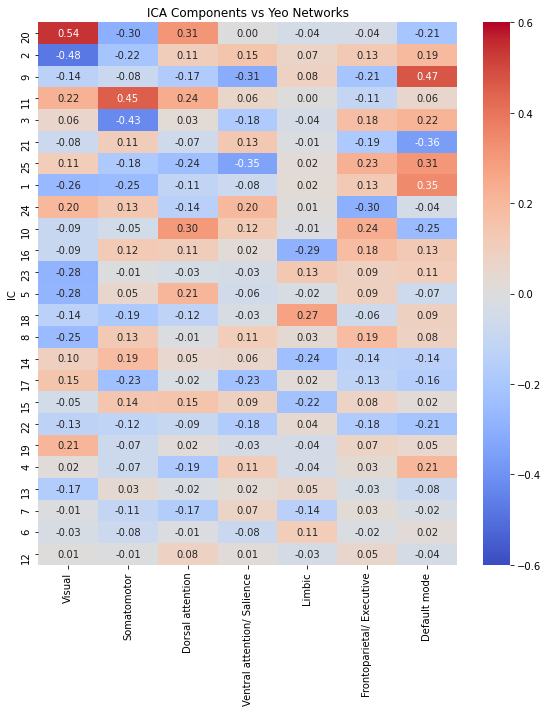

In [7]:
import seaborn as sns

# Yeo network columns to display
corr_cols = [
    "Visual",
    "Somatomotor",
    "Dorsal attention",
    "Ventral attention/ Salience",
    "Limbic",
    "Frontoparietal/ Executive",
    "Default mode"
]

# Create figure
plt.figure(figsize=(8,10))

# Plot heatmap of correlations between ICA components and Yeo networks
sns.heatmap(
    ic_match_df.set_index("IC")[corr_cols],  # Rows = ICs, columns = Yeo networks
    cmap="coolwarm",                         # Red = positive, blue = negative
    center=0,                                # White represents zero correlation
    vmin=-0.6,
    vmax=0.6,
    annot=True,                              # Show correlation values
    fmt=".2f"                                # Display with 2 decimal places
)

plt.title("ICA Components vs Yeo Networks")

plt.tight_layout()                           # Prevent labels from being cut off
plt.savefig(
    "ICA_Yeo_heatmap.png",
    dpi=300                                  # Save high-resolution figure
)
plt.show()

In [8]:
# Select the top 10 ICs with the strongest Yeo correlations

keep_ics = (
    ic_match_df
    .sort_values("Abs best r", ascending=False)
    .head(10)
    ["IC"]
    .astype(int)
    .tolist()
)

print("Selected ICs from train only:", keep_ics)
print("Number selected:", len(keep_ics))

Selected ICs from train only: [20, 2, 9, 11, 3, 21, 25, 1, 24, 10]
Number selected: 10


In [9]:
# Estimate subject-specific ICA time courses
# and spatial maps from the group ICA maps.

def dual_regression(
    subject_data_list,
    group_ic_maps_z,
    keep_ics
):

    # Select the ICs to keep

    # Convert IC numbering from
    # 1-based to Python's 0-based indexing.
    keep_ic_indices = [
        i - 1
        for i in keep_ics
    ]

    # Build the group IC matrix

    # Select the chosen group IC maps.
    # Shape:
    # (n_keep, n_voxels)
    G = group_ic_maps_z[
        keep_ic_indices,
        :
    ]

    # Transpose so that:
    # voxels × ICs
    #
    # This is the form needed for
    # spatial regression.
    G = G.T

    # Store subject-level results

    subject_timecourses = []

    subject_spatial_maps = []
    
    # Process one subject at a time

    for subj_idx, ts in enumerate(
        subject_data_list
    ):

        # Step 1: Spatial Regression
        # Estimate subject-specific
        # IC time courses.
        timecourses = np.linalg.lstsq(
            G,
            ts.T,
            rcond=None
        )[0].T

        # Step 2: Temporal Regression
        # Estimate subject-specific
        # IC spatial maps.

        spatial_maps = np.linalg.lstsq(
            timecourses,
            ts,
            rcond=None
        )[0]

        # Save this subject

        subject_timecourses.append(
            timecourses
        )

        subject_spatial_maps.append(
            spatial_maps
        )

    return (
        np.array(subject_timecourses),
        np.array(subject_spatial_maps)
    )

In [10]:
# Step: Compute Functional Network Connectivity

# Compute subject-level functional
# network connectivity (FNC) from
# the IC time courses.

def compute_fnc(subject_timecourses):

    # Store FNC matrices
    fnc_matrices = []

    # Process one subject at a time
    for subj_idx in range(
        subject_timecourses.shape[0]
    ):

        # Get this subject's
        # IC time courses
        T = subject_timecourses[
            subj_idx
        ]

        # Calculate Pearson correlations
        # between all IC pairs.
        #
        # Input:
        # time × IC
        #
        # Output:
        # IC × IC connectivity matrix.

        corr = np.corrcoef(
            T.T
        )

        # Convert correlation values
        # to Fisher z scores for
        # statistical analysis.

        corr_z = np.arctanh(
            np.clip(
                corr,
                -0.999999,
                0.999999
            )
        )

        # Save this subject's FNC
        fnc_matrices.append(
            corr_z
        )

    # Return all subjects
    return np.array(
        fnc_matrices
    )


# Run Dual Regression

# Estimate subject-specific
# IC time courses and
# spatial maps.

train_timecourses, train_spatial_maps = dual_regression(
    train_subject_data,
    train_ica_space_z,
    keep_ics
)

# Compute Training FNC

train_fnc = compute_fnc(
    train_timecourses
)

print(
    "Train FNC:",
    train_fnc.shape
)

Train FNC: (101, 10, 10)


In [11]:
# Step: Convert FNC matrices into ML features

def fnc_to_features(
    fnc_matrices,
    keep_ics
):

    # Count selected ICs
    n_selected = len(
        keep_ics
    )

    # Get unique IC pairs

    # Keep only the upper triangle
    # of the FNC matrix.

    triu_idx = np.triu_indices(
        n_selected,
        k=1
    )

    # Extract connectivity features

    # Convert each subject's
    # FNC matrix into a
    # feature vector by taking
    # the unique IC connections.

    X = fnc_matrices[
        :,
        triu_idx[0],
        triu_idx[1]
    ]

    # Create feature labels

    # Name each feature by
    # the IC pair it represents.

    feature_names = [

        f"IC{keep_ics[i]}-IC{keep_ics[j]}"

        for i, j in zip(
            triu_idx[0],
            triu_idx[1]
        )

    ]

    return X, feature_names

# Build training feature matrix

# Convert the training FNC
# matrices into ML features.

X_train, feature_names = fnc_to_features(
    train_fnc,
    keep_ics
)


# Check output dimensions


print(
    "X_train:",
    X_train.shape
)

print(
    "features:",
    len(feature_names)
)

X_train: (101, 45)
features: 45


In [12]:
# Step: Train a Logistic Regression classifier


from sklearn.linear_model import LogisticRegressionCV


# Step 1:
# Standardize the features.
#
# Step 2:
# Train an L1-regularized
# logistic regression model.

clf = Pipeline([

    # Feature scaling

    # Normalize all features
    # to a similar scale.
    #
    # Why?
    # Prevent features with
    # larger values from
    # dominating the model.

    (
        "scaler",
        StandardScaler()
    ),

    # Logistic Regression
    (
        "model",

        LogisticRegressionCV(

            # Use L1 regularization
            # for automatic feature
            # selection.
            penalty="l1",

            # Optimization algorithm
            # supporting L1 penalty.
            solver="saga",

            # Try 10 different
            # regularization strengths.
            Cs=10,

            # Use 5-fold cross
            # validation to choose
            # the best C value.
            cv=5,

            # Optimize ROC AUC.
            scoring="roc_auc",

            # Maximum optimization
            # iterations.
            max_iter=1000,

            # Make results reproducible.
            random_state=random_state

        )
    )
])


# Learn the relationship
# between FNC features
# and diagnosis.
#Take the training subjects, normalize their FNC 
#features, and learn the coefficients of a logistic 
#regression model that best separates schizophrenia 
#patients from healthy controls while using L1 regularization and cross-validation to avoid overfitting.
clf.fit(
    X_train,
    y_train
)

# Predict HC (0)
# or SZ (1).

train_pred = clf.predict(
    X_train
)


# Estimate the probability
# that each subject belongs
# to the SZ group.

train_prob = clf.predict_proba(
    X_train
)[:,1]


# Compute training accuracy.

print(
    "Train accuracy:",
    accuracy_score(
        y_train,
        train_pred
    )
)

# Compute training ROC AUC.

print(
    "Train AUC:",
    roc_auc_score(
        y_train,
        train_prob
    )
)

Train accuracy: 0.8217821782178217
Train AUC: 0.8351648351648352


In [13]:
# Process the test subjects
# using the same pipeline
# as the training set.

test_subject_data = files_to_timeseries(
    test_files,
    name="Test",
    fit_masker=False
)

# Project the group ICA
# networks onto the
# test subjects.

test_timecourses, test_spatial_maps = dual_regression(
    test_subject_data,
    train_ica_space_z,
    keep_ics
)

# Compute subject-level
# functional network
# connectivity.

test_fnc = compute_fnc(
    test_timecourses
)

# Convert FNC matrices
# into ML feature vectors.

X_test, _ = fnc_to_features(
    test_fnc,
    keep_ics
)

print(
    "X_test:",
    X_test.shape
)


# Apply the trained model
# to unseen subjects.
# Predict HC or SZ.

test_pred = clf.predict(
    X_test
)

# Predict the probability
# of schizophrenia.

test_prob = clf.predict_proba(
    X_test
)[:,1]


# Overall classification accuracy.

print(
    "Test accuracy:",
    accuracy_score(
        y_test,
        test_pred
    )
)

# ROC AUC.

print(
    "Test AUC:",
    roc_auc_score(
        y_test,
        test_prob
    )
)

# Confusion matrix.

print(
    "Confusion matrix:"
)

print(
    confusion_matrix(
        y_test,
        test_pred
    )
)

# Precision, recall,
# and F1 score.

print(
    classification_report(
        y_test,
        test_pred,
        target_names=[
            "Control",
            "Patient"
        ]
    )
)

Test: 1/44 fmri_0040006.nii.gz
Test: 2/44 fmri_0040062.nii.gz
Test: 3/44 fmri_0040140.nii.gz
Test: 4/44 fmri_0040014.nii.gz
Test: 5/44 fmri_0040036.nii.gz
Test: 6/44 fmri_0040010.nii.gz
Test: 7/44 fmri_0040046.nii.gz
Test: 8/44 fmri_0040071.nii.gz
Test: 9/44 fmri_0040022.nii.gz
Test: 10/44 fmri_0040039.nii.gz
Test: 11/44 fmri_0040080.nii.gz
Test: 12/44 fmri_0040041.nii.gz
Test: 13/44 fmri_0040052.nii.gz
Test: 14/44 fmri_0040051.nii.gz
Test: 15/44 fmri_0040000.nii.gz
Test: 16/44 fmri_0040118.nii.gz
Test: 17/44 fmri_0040008.nii.gz
Test: 18/44 fmri_0040016.nii.gz
Test: 19/44 fmri_0040007.nii.gz
Test: 20/44 fmri_0040066.nii.gz
Test: 21/44 fmri_0040136.nii.gz
Test: 22/44 fmri_0040134.nii.gz
Test: 23/44 fmri_0040054.nii.gz
Test: 24/44 fmri_0040095.nii.gz
Test: 25/44 fmri_0040117.nii.gz
Test: 26/44 fmri_0040108.nii.gz
Test: 27/44 fmri_0040109.nii.gz
Test: 28/44 fmri_0040084.nii.gz
Test: 29/44 fmri_0040116.nii.gz
Test: 30/44 fmri_0040103.nii.gz
Test: 31/44 fmri_0040144.nii.gz
Test: 32/44 fmri_

In [14]:
# Perform an independent
# t-test for every FNC feature.

feature_results = []

for i, feature in enumerate(feature_names):

    # Extract this feature
    # for healthy controls.
    hc = X_train[
        y_train == 0,
        i
    ]

    # Extract this feature
    # for schizophrenia patients.
    sz = X_train[
        y_train == 1,
        i
    ]

    # Compare the two groups.
    t, p = ttest_ind(
        hc,
        sz,
        equal_var=False
    )

    # Save the statistics.
    feature_results.append({

        "Feature": feature,

        "t": t,

        "p": p,

        "HC mean": hc.mean(),

        "SZ mean": sz.mean(),

        "Difference":
        sz.mean() - hc.mean()

    })


# Correct for multiple
# statistical tests using FDR.

results_df = pd.DataFrame(
    feature_results
)

# Apply FDR correction
# to the p-values.

reject, p_fdr = fdrcorrection(
    results_df["p"]
)

# Store the corrected
# p-values.

results_df["p_fdr"] = p_fdr

# Store whether each
# feature survives FDR.

results_df["Significant"] = reject

# Sort by corrected
# p-value.

results_df = results_df.sort_values(
    "p_fdr"
)

# Keep only significant
# features.

sig_edges = results_df[
    results_df["Significant"] == True
].copy()

# Display significant edges.

sig_edges

,Feature,t,p,HC mean,SZ mean,Difference,p_fdr,Significant
18,IC9-IC3,3.699665,0.000359,0.08809,-0.072667,-0.160757,0.016165,True


In [15]:
results_df.head(10)

,Feature,t,p,HC mean,SZ mean,Difference,p_fdr,Significant
18,IC9-IC3,3.699665,0.000359,0.088090,-0.072667,-0.160757,0.016165,True
17,IC9-IC11,2.262594,0.025887,-0.098096,-0.227860,-0.129764,0.388304,False
9,IC2-IC9,2.275068,0.025059,0.000421,-0.099427,-0.099848,0.388304,False
7,IC20-IC24,2.016001,0.046543,0.054974,-0.032560,-0.087533,0.523610,False
21,IC9-IC1,-1.781195,0.078065,-0.054793,0.019622,0.074415,0.585485,False
39,IC25-IC1,1.801817,0.074751,0.001018,-0.081153,-0.082171,0.585485,False
34,IC3-IC10,1.626832,0.106999,0.011419,-0.059752,-0.071170,0.601868,False
30,IC3-IC21,1.663671,0.099415,0.216464,0.142239,-0.074226,0.601868,False
19,IC9-IC21,1.485817,0.140517,0.100306,0.034992,-0.065315,0.618590,False
11,IC2-IC3,-1.446451,0.151211,0.013902,0.080771,0.066870,0.618590,False


In [16]:
# Permutation test for independent test AUC


from sklearn.base import clone
from sklearn.metrics import roc_auc_score
import numpy as np
import matplotlib.pyplot as plt

n_perm = 1000
rng = np.random.default_rng(42)

# True model performance
true_test_prob = clf.predict_proba(X_test)[:, 1]
true_auc = roc_auc_score(y_test, true_test_prob)

perm_aucs = []

for i in range(n_perm):
    if (i + 1) % 100 == 0:
        print(f"Permutation {i+1}/{n_perm}")

    # only shuffle training labels
    y_train_perm = rng.permutation(y_train)

    # clone a new classifier
    perm_clf = clone(clf)

    # train using random tags
    perm_clf.fit(X_train, y_train_perm)

    # make predictions on true test set
    perm_prob = perm_clf.predict_proba(X_test)[:, 1]

    # calculate permutation AUC
    perm_auc = roc_auc_score(y_test, perm_prob)
    perm_aucs.append(perm_auc)

perm_aucs = np.array(perm_aucs)

# one-sided permutation p-value
p_perm = (np.sum(perm_aucs >= true_auc) + 1) / (n_perm + 1)

print("True test AUC:", true_auc)
print("Permutation p-value:", p_perm)
print("Mean permuted AUC:", perm_aucs.mean())
print("SD permuted AUC:", perm_aucs.std())

Permutation 100/1000
Permutation 200/1000
Permutation 300/1000
Permutation 400/1000
Permutation 500/1000
Permutation 600/1000
Permutation 700/1000
Permutation 800/1000
Permutation 900/1000
Permutation 1000/1000
True test AUC: 0.8512396694214877
Permutation p-value: 0.000999000999000999
Mean permuted AUC: 0.4996611570247934
SD permuted AUC: 0.09813688779796469


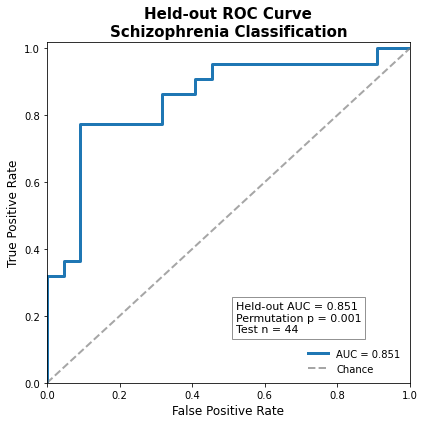

In [17]:
perm_p_value = 0.000999000999000999
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(
    y_test,
    test_prob
)

plt.figure(figsize=(6, 6))

plt.plot(
    fpr,
    tpr,
    linewidth=3,
    label=f"AUC = {true_auc:.3f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    "--",
    color="gray",
    linewidth=2,
    alpha=0.7,
    label="Chance"
)

plt.xlim(0, 1)
plt.ylim(0, 1.02)

plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)

plt.title(
    "Held-out ROC Curve\nSchizophrenia Classification",
    fontsize=15,
    fontweight="bold"
)

plt.text(
    0.52,
    0.15,
    f"Held-out AUC = {true_auc:.3f}\n"
    f"Permutation p = {perm_p_value:.3f}\n"
    f"Test n = {len(y_test)}",
    fontsize=11,
    bbox=dict(
        facecolor="white",
        alpha=0.85,
        edgecolor="gray"
    )
)

plt.legend(loc="lower right", frameon=False)

plt.tight_layout()

plt.savefig(
    "heldout_roc_curve.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [18]:
from nilearn import plotting, image
import numpy as np

top10_df = (
    ic_match_df
    .sort_values("Abs best r", ascending=False)
    .head(10)
)

for _, row in top10_df.iterrows():

    ic = int(row["IC"])
    network = row["Best match"]
    r = row["Best r"]

    # 1D IC vector inside mask
    ic_vec = train_ica_space_z[ic - 1]

    # Put 1D vector back into 3D brain space
    ic_3d = np.zeros(mask_data.shape)
    ic_3d[mask_data] = ic_vec

    # Convert 3D array to NIfTI image
    ic_img = image.new_img_like(
        mask_img,
        ic_3d
    )

    title = f"IC{ic} | {network} | r={r:.3f}"

    display = plotting.plot_stat_map(
        ic_img,
        title=title,
        threshold=2.0,
        display_mode="ortho",
        cmap="cold_hot",
        black_bg=True,
        colorbar=True
    )

    safe_network = (
        network
        .replace("/", "_")
        .replace(" ", "_")
    )

    display.savefig(
        f"IC{ic}_{safe_network}.png",
        dpi=300
    )

    display.close()

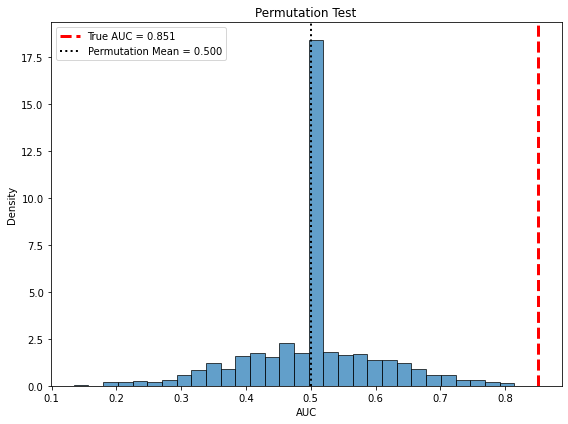

In [19]:
# Publication-style permutation histogram

plt.figure(figsize=(8,6))

plt.hist(
    perm_aucs,
    bins=30,
    density=True,
    alpha=0.7,
    edgecolor="black"
)

plt.axvline(
    true_auc,
    color="red",
    linestyle="--",
    linewidth=3,
    label=f"True AUC = {true_auc:.3f}"
)

plt.axvline(
    np.mean(perm_aucs),
    color="black",
    linestyle=":",
    linewidth=2,
    label=f"Permutation Mean = {np.mean(perm_aucs):.3f}"
)

plt.xlabel("AUC")
plt.ylabel("Density")
plt.title("Permutation Test")

plt.legend()

plt.tight_layout()

plt.savefig(
    "Permutation_Test_AUC.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

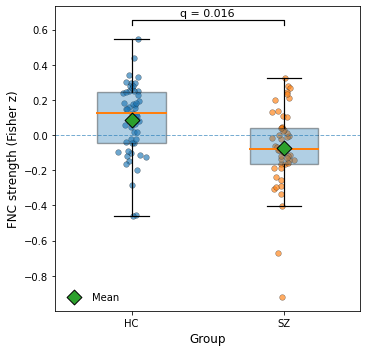

In [20]:
# Plot the strongest significant FNC edge:
# Default Mode Network – Somatomotor Network.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

target_feature = "IC9-IC3"   # DMN–Somatomotor in your current result

# Find the column index for this FNC feature
feature_idx = feature_names.index(target_feature)

# Extract values for HC and SZ
hc_values = X_train[y_train == 0, feature_idx]
sz_values = X_train[y_train == 1, feature_idx]

# Get statistics from results_df

row = results_df[
    results_df["Feature"] == target_feature
].iloc[0]

t_value = row["t"]
p_value = row["p"]
q_value = row["p_fdr"]

# Cohen's d
pooled_sd = np.sqrt(
    ((len(hc_values) - 1) * np.var(hc_values, ddof=1)
     + (len(sz_values) - 1) * np.var(sz_values, ddof=1))
    / (len(hc_values) + len(sz_values) - 2)
)

cohen_d = (
    hc_values.mean() - sz_values.mean()
) / pooled_sd

# Build dataframe for plotting
plot_df = pd.DataFrame({
    "Group": (
        ["Healthy Controls"] * len(hc_values)
        + ["Schizophrenia"] * len(sz_values)
    ),
    "FNC": np.concatenate([hc_values, sz_values])
})

plt.figure(figsize=(5.2, 5.0))

data = [hc_values, sz_values]

# Boxplot
box = plt.boxplot(
    data,
    labels=["HC", "SZ"],
    widths=0.45,
    patch_artist=True,
    showfliers=False,
    medianprops=dict(linewidth=2),
    boxprops=dict(linewidth=1.4),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2)
)

for patch in box["boxes"]:
    patch.set_alpha(0.35)

# Individual points
rng = np.random.default_rng(42)

for i, values in enumerate(data, start=1):
    x = rng.normal(i, 0.045, size=len(values))
    plt.scatter(
        x,
        values,
        alpha=0.65,
        s=32,
        edgecolor="black",
        linewidth=0.35
    )

# Group means
means = [hc_values.mean(), sz_values.mean()]

plt.scatter(
    [1, 2],
    means,
    s=110,
    marker="D",
    edgecolor="black",
    linewidth=1,
    zorder=5,
    label="Mean"
)

# Zero line
plt.axhline(
    0,
    linestyle="--",
    linewidth=1,
    alpha=0.6
)

# Axis labels
plt.ylabel("FNC strength (Fisher z)", fontsize=12)
plt.xlabel("Group", fontsize=12)

plt.title("")

# Significance bar

y_max = max(hc_values.max(), sz_values.max())
y_min = min(hc_values.min(), sz_values.min())

bar_y = y_max + 0.08
bar_h = 0.025

plt.plot(
    [1, 1, 2, 2],
    [bar_y, bar_y + bar_h, bar_y + bar_h, bar_y],
    linewidth=1.2,
    color="black"
)

plt.text(
    1.5,
    bar_y + bar_h + 0.015,
    f"q = {q_value:.3f}",
    ha="center",
    va="bottom",
    fontsize=11
)

# Adjust y-limit so significance bar fits
plt.ylim(y_min - 0.08, bar_y + bar_h + 0.08)

plt.legend(frameon=False, loc="lower left")

plt.tight_layout()

# Save

plt.savefig(
    "DMN_Somatomotor_group_comparison_publication_style.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    "DMN_Somatomotor_group_comparison_publication_style.pdf",
    bbox_inches="tight"
)

plt.show()